In [66]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [67]:
from pycbc.detector import Detector

In [68]:
ifo1 = Detector("L1")
ifo2 = Detector("H1")
ifo3 = Detector("V1")

In [111]:
N = 1000000
t_gps=uniform(0, 12345678, N)
right_ascension=uniform(0, 2*pi, N)#[0]*N
declination=arcsin(uniform(-1, 1, N))#[0]*N

In [70]:
ifo1.time_delay_from_location??

In [112]:
for i in range(10):
    t_diff12 = ifo1.time_delay_from_detector(ifo2, right_ascension, declination, t_gps)
    t_diff21 = ifo2.time_delay_from_detector(ifo1, right_ascension, declination, t_gps)
    t_diff31 = ifo3.time_delay_from_detector(ifo1, right_ascension, declination, t_gps)
    t_diff32 = ifo3.time_delay_from_detector(ifo2, right_ascension, declination, t_gps)

In [113]:
# convert to ms
t_diff12 *= 1000
t_diff21 *= 1000
t_diff31 *= 1000
t_diff32 *= 1000

In [114]:
max(t_diff12), max(t_diff21), min(t_diff21)

(10.012800758401756, 10.012830325487258, -10.012800758401756)

In [71]:
ifo1.light_travel_time_to_detector(ifo2)

0.010012846152223925

In [72]:
ifo2.light_travel_time_to_detector(ifo3)

0.027287979933844225

In [74]:
ifo1.light_travel_time_to_detector(ifo3)

0.026448341016726495

In [67]:
ifo2.light_travel_time_to_detector(ifo1)

0.010012846152223925

In [64]:
sqrt(3)

1.7320508075688772

In [59]:
ifo1.light_travel_time_to_detector(ifo3)

0.026448341016726495

In [39]:
max(t_diff32), max(t_diff31)

(27.277950983480284, 26.166566194301392)

In [84]:
hist_kwargs = dict(bins=30, density=True, histtype="step")

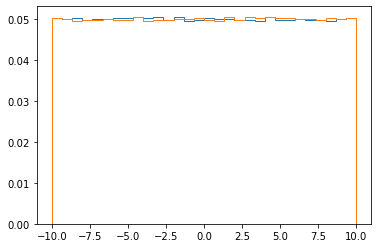

In [115]:
hist(t_diff12, **hist_kwargs);
hist(t_diff21, **hist_kwargs);

In [142]:
def get_bounds(dt, a=0.010012846152223925*1000, c=0.027287979933844225*1000):
    dt_2 = c * sqrt(1-dt**2/a**2)
    return -dt_2, dt_2

def get_bounds_2(dt, eps=0.01):
    idx = (t_diff21<dt+eps)&(t_diff21>dt-eps)
    dt2 = t_diff32[idx]
    return min(dt2), max(dt2)

In [153]:
dt = linspace(-10.01, 10.01, 50)
b1 = get_bounds(dt)
b2 = array([get_bounds_2(i) for i in dt]).T

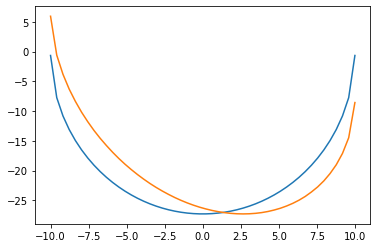

In [154]:
plot(dt, b1[0])
plot(dt, b2[0])

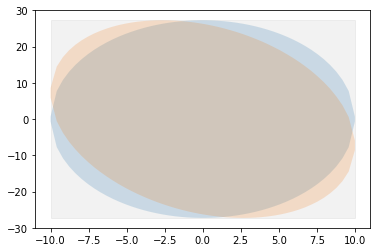

In [160]:
fill_between(dt, b1[0], b1[1], alpha=0.2)
fill_between(dt, b2[0], b2[1], alpha=0.2)
c = 0.027287979933844225*1000
fill_between(dt, -c, c, alpha=0.1, color="grey")

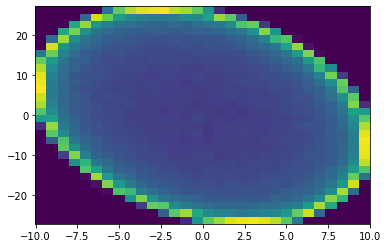

In [164]:
hist2d(t_diff21, t_diff32, bins=30);

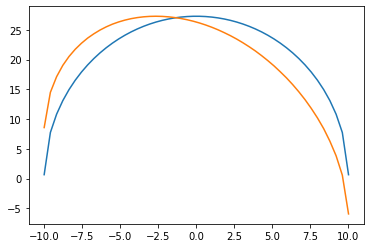

In [155]:
plot(dt, b1[1])
plot(dt, b2[1])

In [146]:
get_bounds(9)

(-11.959393399249803, 11.959393399249803)

In [147]:
get_bounds_2(9)

(-18.09383435236984, 5.062450153707414)

In [148]:
ii = where(t_diff32 == -18.09383435236984)
ii

(array([73076]),)

In [152]:
t_diff21[ii], right_ascension[ii], declination[ii]

(array([8.99054714]), array([5.33417897]), array([-0.3666775]))

988


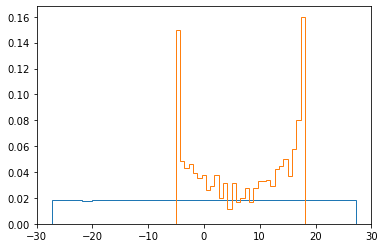

In [110]:
hist(t_diff32, **hist_kwargs);
eps = 0.01
dt = 9
idx = (t_diff12<dt+eps)&(t_diff12>dt-eps)
print(sum(idx))
hist(t_diff32[idx], **hist_kwargs);

1036


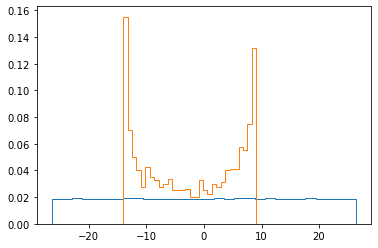

In [118]:
hist(t_diff31, **hist_kwargs);
eps = 0.01
dt = 9
idx = (t_diff12<dt+eps)&(t_diff12>dt-eps)
print(sum(idx))
hist(t_diff31[idx], **hist_kwargs);

In [50]:
min(abs(t_diff32[idx]))

(26.142111160103283, 26.143798724493827)

In [52]:
len(t_diff32[idx])

36

### Search arrays

In [5]:
t1 = uniform(0,1,10)
t2 = uniform(0,1,10)
t3 = uniform(0,0.6,10)
t2_coinc_window = 2 
t3_coinc_window = 3

In [53]:
id(t1), id(t1[1]), id(t1)

(140396457007904, 140396988132432, 140396457007904)

In [60]:
ii = slice(-1,4)

In [62]:
from ligo.segments import segment

In [169]:
t1*array([t2]*10)[t2_perms]

IndexError: arrays used as indices must be of integer (or boolean) type

In [172]:
type(t2_perms[0])

list

[0, 1, 2, None]

In [170]:
t2_perms

array([list([0, 1, 2]), list([0, 1, 2, 3]), list([0, 1, 2, 3, 4]),
       list([1, 2, 3, 4, 5]), list([2, 3, 4, 5, 6]),
       list([3, 4, 5, 6, 7]), list([4, 5, 6, 7, 8]),
       list([5, 6, 7, 8, 9]), list([6, 7, 8, 9]), list([7, 8, 9])],
      dtype=object)

In [166]:
t2_perms = array([
    [0,1,2],
    [0,1,2,3],
    [0,1,2,3,4],
    [1,2,3,4,5],
    [2,3,4,5,6],
    [3,4,5,6,7],
    [4,5,6,7,8],
    [5,6,7,8,9],
    [6,7,8,9],
    [7,8,9],
])
t3_perms = array([
    [0,1,2,3], 
    [0,1,2,3,4],
    [0,1,2,3,4,5],
    [0,1,2,3,4,5,6],
    [1,2,3,4,5,6,7],
    [2,3,4,5,6,7,8],
    [3,4,5,6,7,8,9],
    [4,5,6,7,8,9],
    [5,6,7,8,9],
    [6,7,8,9],
])

/var/folders/2n/44xg31f92bd49rgkf9bsy4j80000gq/T/ipykernel_18787/3937878340.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  t2_perms = array([
/var/folders/2n/44xg31f92bd49rgkf9bsy4j80000gq/T/ipykernel_18787/3937878340.py:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  t3_perms = array([
